# Batch Heuristics Pipeline v3 — corrected scale, robustness suite

**Goal:** produce the activation results, the threshold-robustness evidence and the
validity evidence requested by Reviewer 2 ("thresholds not yet independently
validated; inconsistencies in definitions and units remain").

## What changed relative to v2

| # | Change | Why |
|---|--------|-----|
| 1 | Brake-scale corrections applied **before** any result is produced (`PEDAL_ACTIVE_PCT = 5.0`, `OVERBRAKE_DELTA = 15.0`, `LEGACY_BRAKE_GATE = 5.0`) | v2 audited the scale in §8 but ran §4-§9 with the pre-audit values, so every result was anchored at thresholds the manuscript does not declare |
| 2 | Descriptor parameters (`PEDAL_ACTIVE_PCT`, `MIN_BRAKE_RUN`) moved into `DESC_SPEC` | in v2 these were module constants, invisible to the sensitivity analysis, although the pedal-active threshold is the most influential constant in the pipeline |
| 3 | Two-stage cache: telemetry -> `interp_cache`, descriptors -> `heur_cache(desc_params)` | lets descriptors be recomputed under different `DESC_SPEC` values without reloading `.ibt` files |
| 4 | Explicit legacy-vs-corrected delta table | the size of the correction belongs in the response letter |
| 5 | OAT factor grid widened to 0.25x-3.0x | a wide sweep that preserves the conclusion is stronger evidence than a narrow one; the breaking point of each rule is more informative than its absence |
| 6 | Added joint Monte Carlo perturbation (all thresholds at once) | under OAT, 10 of 12 rule counts are unchanged by construction, so Kendall tau is near 1 regardless of robustness |
| 7 | `pattern_ok` binary replaced by continuous slope margins | True/False collapses the effect size and hides how close a scenario came to flipping |
| 8 | Descriptor-level sweep of `PEDAL_ACTIVE_PCT` and `MIN_BRAKE_RUN` | closes the gap in item 2 |
| 9 | Negative control and convergent validity recomputed under both threshold sets | tests whether the scale correction improved specificity |

**Run order:** §1 -> §11 top to bottom. §4 loads telemetry once; everything after
that is cheap.

## 1. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter

# notebook lives in Iracing/Notebooks/ -> go up one level
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import (TRACK_CONFIGS, DATASETS, DRIVER_ALIAS, resolve_stint_files,
                    basic_clean_and_units, build_lap_validity_table, load_stint)

RNG = np.random.default_rng(20250813)   # reproducible Monte Carlo

print(f"Tracks : {list(TRACK_CONFIGS.keys())}")
print(f"Drivers: {DRIVER_ALIAS}")

Tracks : ['charlotte_roval_2025', 'summit_point']
Drivers: {'Rodrigo': 'Driver A', 'Tomaz': 'Driver B', 'Morsinaldo': 'Driver C', 'Thallys': 'Driver D', 'Igor': 'Driver E', 'Hilton': 'Driver F'}


## 2. Batch configuration

`COMPARISONS`: chained proficiency comparisons — **not** a single global reference.

- **B vs. A** (intermediate vs. expert)
- **C vs. B**, **D vs. B**, **E vs. B**, **F vs. B** (each amateur vs. the intermediate)

Driver A never appears as `test`; Driver B never appears as `ref` in the amateur group.

In [2]:
COMPARISONS = [
    {"ref": "Rodrigo",     "ref_stint": "stint_1",   "test": "Tomaz",      "label": "B vs. A"},
    {"ref": "Tomaz",       "ref_stint": "stint_ref", "test": "Morsinaldo", "label": "C vs. B"},
    {"ref": "Tomaz",       "ref_stint": "stint_ref", "test": "Thallys",    "label": "D vs. B"},
    {"ref": "Tomaz",       "ref_stint": "stint_ref", "test": "Igor",       "label": "E vs. B"},
    {"ref": "Tomaz",       "ref_stint": "stint_ref", "test": "Hilton",     "label": "F vs. B"},
]
comp_order = [c["label"] for c in COMPARISONS]

EXCLUDE_STINTS = {"warmup", "stint_ref"}
TRACK_SHORT    = {"charlotte_roval_2025": "CLT", "summit_point": "SPT"}
BASE_GRID_LEN  = 2000

# Longitudinal design: pairs that received feedback vs. the untreated control.
FEEDBACK_PAIRS = ["B vs. A", "C vs. B", "D vs. B", "F vs. B"]
CONTROL_PAIR   = "E vs. B"

SAVE_DIR = Path(PROJECT_ROOT) / "img" / "batch_heuristics_v3"
SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {SAVE_DIR}")

Output directory: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\batch_heuristics_v3


## 3. Descriptors — parameterized

**Unit convention (single source of truth; Table 2 of the manuscript must match):**

| Quantity | Unit |
|---|---|
| Pedal inputs (brake, throttle) | % on a 0–100 scale |
| Lap distance (`LapDistPct`) | fraction, 0–1 |
| Time | s |
| Speed | km/h |
| Steering angle | rad |
| Yaw rate | rad/s |
| Longitudinal acceleration | m/s² |

`DESC_SPEC` holds the two descriptor-level constants. In v2 these were hard-coded
(`0.05`, meaning 0.05 % on a 0–100 channel — pedal noise). They are now explicit
parameters so §10 can sweep them.

`PEDAL_ACTIVE_PCT` feeds four descriptors (`BrakeStartDist`, `BrakeEfficiency`,
`BrakeRampRate`, `BrakeConsistency`) plus the throttle mask, which is why it cannot
be swept through `TH` alone — it changes the descriptors themselves, not the rules.

In [3]:
# --- Descriptor-level parameters ---------------------------------------------
DESC_SPEC = {
    "PEDAL_ACTIVE_PCT": 5.0,   # %  -- pedal considered engaged (masks M_b, M_t)
    "MIN_BRAKE_RUN":    5,     # consecutive samples on the 2000-pt/lap grid
}

# Pre-correction values, kept only to quantify the effect of the fix (§5).
DESC_LEGACY = {
    "PEDAL_ACTIVE_PCT": 0.05,  # 0.05 % on a 0-100 channel -> pedal noise
    "MIN_BRAKE_RUN":    5,
}

EPS = 1e-6


def compute_derivatives(sec):
    """Pedal rates in %/s, Savitzky-Golay smoothed (window <= 9, order 3).

    The sector arrays come from a grid that is uniform in LapDistPct, NOT in
    time (time-per-sample shrinks on straights and grows in slow corners /
    braking zones). A single mean dt fed to np.gradient would silently assume
    uniform time spacing and bias the rate exactly where it matters most.
    np.gradient(y, t) with the real, non-uniform t_rel array handles this
    correctly (unequal-spacing finite differences)."""
    t = sec["t_rel"]
    if len(t) > 1:
        brake_rate    = np.gradient(sec["brake"],    t)
        throttle_rate = np.gradient(sec["throttle"], t)
    else:
        brake_rate    = np.zeros_like(sec["brake"])
        throttle_rate = np.zeros_like(sec["throttle"])
    window = min(9, len(brake_rate))
    if window > 3 and window % 2 != 0:
        brake_rate    = savgol_filter(brake_rate, window, 3)
        throttle_rate = savgol_filter(throttle_rate, window, 3)
    return brake_rate, throttle_rate


def braking_heuristics(sec, brake_rate, dp):
    """M_b = {i : b_i > PEDAL_ACTIVE_PCT}. Sector without braking -> zeros."""
    d = {}
    m = sec["brake"] > dp["PEDAL_ACTIVE_PCT"]
    if np.any(m):
        d["BrakeRampRate"]    = float(np.quantile(brake_rate[m], 0.95))    # %/s
        d["BrakeConsistency"] = float(np.var(brake_rate[m]))               # (%/s)^2
        d["BrakeEfficiency"]  = float(abs(np.min(sec["long_accel"][m])) /
                                      (np.max(sec["brake"][m]) + EPS))     # m/s^2 per %
    else:
        d["BrakeRampRate"] = d["BrakeConsistency"] = d["BrakeEfficiency"] = 0.0
    return d


def brake_start_dist(sec, dp):
    """Lap fraction of the first sustained brake application in the sector.
    Sustained = b > PEDAL_ACTIVE_PCT for MIN_BRAKE_RUN consecutive samples.
    NaN when the sector contains no sustained braking."""
    n  = int(dp["MIN_BRAKE_RUN"])
    on = sec["brake"] > dp["PEDAL_ACTIVE_PCT"]
    if on.size < n or not np.any(on):
        return np.nan
    runs = np.convolve(on.astype(int), np.ones(n, dtype=int), mode="valid")
    idx  = np.flatnonzero(runs == n)
    return float(sec["lap_pct"][idx[0]]) if idx.size else np.nan


def rotation_heuristics(sec):
    d = {}
    speed, yaw, steer, t = sec["speed"], sec["yaw_rate"], sec["steering"], sec["t_rel"]
    idx_vmin = np.argmin(speed)
    idx_mrp  = np.argmax(np.abs(yaw))
    d["Vmin"] = float(speed[idx_vmin])                                     # km/h
    # t(Vmin) - t(MRP), in s. Negative => peak rotation occurs AFTER the
    # minimum-speed point (late rotation).
    d["Delta_MRP_Vmin"] = float(t[idx_vmin] - t[idx_mrp])                  # s
    # Trapezoidal integral against the real (non-uniform) time array, not a
    # constant-dt Riemann sum -- same uniform-time-grid pitfall as above.
    d["TrailOverlap"] = (float(np.trapz(sec["brake"] * np.abs(steer), t))
                         if len(t) > 1 else 0.0)                           # %.rad.s
    d["Vmin_Norm"]    = float(d["Vmin"] / (speed[0] + EPS))                # -
    avg_steer = np.mean(np.abs(steer))
    d["RotationEfficiency"] = (float(np.mean(np.abs(yaw)) / (avg_steer + EPS))
                               if avg_steer > 1e-3 else 0.0)               # s^-1
    return d


def acceleration_heuristics(sec, throttle_rate, dp):
    """M_t = {i : t_i > PEDAL_ACTIVE_PCT}."""
    d = {}
    m = sec["throttle"] > dp["PEDAL_ACTIVE_PCT"]
    if np.any(m):
        d["ThrottleAttackRate"]    = float(np.quantile(throttle_rate[m], 0.95))    # %/s
        d["ThrottleSmoothness"]    = float(1.0 / (np.var(throttle_rate[m]) + EPS)) # (%/s)^-2
        d["ThrottleSteerConflict"] = float(np.mean(sec["throttle"] *
                                                   np.abs(sec["steering"])))       # %.rad
        d["AccelEfficiency"]       = float(np.mean(sec["long_accel"][m]) /
                                           (np.mean(sec["throttle"][m]) + EPS))    # m/s^2 per %
    else:
        d["ThrottleAttackRate"] = d["ThrottleSmoothness"] = 0.0
        d["ThrottleSteerConflict"] = d["AccelEfficiency"] = 0.0
    return d


def sector_heuristics(sec_raw, dp):
    sec = {
        "t_rel":      sec_raw["t_rel"],
        "speed":      sec_raw["speed"],
        "brake":      sec_raw["brake"],
        "throttle":   sec_raw["throttle"],
        "steering":   sec_raw["SteeringWheelAngle"],
        "yaw_rate":   sec_raw["YawRate"],
        "long_accel": sec_raw.get("LongAccel", np.zeros_like(sec_raw["speed"])),
        "lap_pct":    sec_raw["LapDistPct"],
    }
    brake_rate, throttle_rate = compute_derivatives(sec)
    h = {
        "SpeedStart":     float(sec["speed"][0]),                        # km/h
        "SpeedEnd":       float(sec["speed"][-1]),                       # km/h
        "BrakePeak":      float(np.max(sec["brake"])),                   # %
        "SteerRMS":       float(np.sqrt(np.mean(sec["steering"] ** 2))), # rad
        "BrakeStartDist": brake_start_dist(sec, dp),                     # lap fraction
    }
    h.update(braking_heuristics(sec, brake_rate, dp))
    h.update(rotation_heuristics(sec))
    h.update(acceleration_heuristics(sec, throttle_rate, dp))
    return h


def compute_sector_heuristics(interp, edges, dp):
    if not interp:
        return pd.DataFrame()
    lap_dist = interp["LapDistPct"]
    rows = []
    for i in range(len(edges) - 1):
        mask = (lap_dist >= edges[i]) & (lap_dist < edges[i + 1])
        if i == len(edges) - 2:
            mask = (lap_dist >= edges[i]) & (lap_dist <= edges[i + 1])
        idx = np.flatnonzero(mask)
        if idx.size == 0:
            continue
        sl = slice(idx[0], idx[-1] + 1)
        sec_raw = {k: v[sl] for k, v in interp.items()}
        sec_raw["t_rel"] = sec_raw["t_rel"] - sec_raw["t_rel"][0]
        h = sector_heuristics(sec_raw, dp)
        h["Sector"]       = i
        h["SectorTime_s"] = float(sec_raw["t_rel"][-1])
        rows.append(h)
    return pd.DataFrame(rows)

In [4]:
# --- Lap alignment (unchanged from v2) ---------------------------------------
def align_lap_by_dist(g: pd.DataFrame, grid: np.ndarray, name: str = "lap"):
    """Resample one lap onto a uniform LapDistPct grid.

    t_rel is anchored on the chronologically-first sample (sorted by
    SessionTime) *before* the distance-sort below, so it is not accidentally
    re-anchored to whichever row happens to have the smallest LapDistPct.
    LapDistPct should increase monotonically over a clean lap; if it ever
    decreases (spin / wheelspin jitter), sorting by distance would splice
    out-of-time-order samples together, so that case is flagged here.
    """
    g = g.sort_values("SessionTime")
    if g.empty:
        return {}
    t_rel_chrono = (g["SessionTime"] - g["SessionTime"].iloc[0]).to_numpy()
    dist_chrono  = g["LapDistPct"].to_numpy()

    backward = np.diff(dist_chrono) < -1e-6
    if backward.any():
        print(f"[WARN] [{name}] LapDistPct decreases at {int(backward.sum())} "
              f"sample(s) (max backward jump = {-np.diff(dist_chrono)[backward].min():.5f}); "
              f"distance-sort interpolation may splice out-of-time-order samples.")

    g = g.assign(t_rel=t_rel_chrono).sort_values("LapDistPct") \
         .drop_duplicates(subset=["LapDistPct"], keep="first")
    x = g["LapDistPct"].to_numpy()
    if len(x) < 2 or np.allclose(x.max() - x.min(), 0):
        return {}
    interp = lambda y: np.interp(grid, x, y)
    return {
        "LapDistPct": grid,
        "t_rel":      interp(g["t_rel"].to_numpy()),
        "speed":      interp(g["Speed_KPH"].to_numpy()),
        "throttle":   interp(g["Throttle_Pct"].to_numpy()),
        "brake":      interp(g["Brake_Pct"].to_numpy()),
        "SteeringWheelAngle": interp(g["SteeringWheelAngle"].to_numpy()),
        "YawRate":    interp(g.get("YawRate",   pd.Series(np.zeros_like(x))).to_numpy()),
        "LongAccel":  interp(g.get("LongAccel", pd.Series(np.zeros_like(x))).to_numpy()),
    }


def assert_pedal_scale(interp, name="lap"):
    """Fail loudly if the pedal channels are not on a 0-100 scale.
    Every absolute brake threshold in THRESHOLD_SPEC assumes percent."""
    for ch in ("brake", "throttle"):
        vmax = float(np.max(interp[ch]))
        if vmax <= 1.5:
            raise ValueError(
                f"[{name}] channel '{ch}' peaks at {vmax:.3f}: looks like a 0-1 scale. "
                f"All thresholds assume 0-100. Fix basic_clean_and_units() or rescale.")
    return True

## 4. `DRIVING_RULES` — parameterized thresholds

`THRESHOLD_SPEC` stores each numeric trigger as `(neutral, margin)`:

$$\theta(f) = \text{neutral} + \text{margin}\times f, \qquad f=1 \text{ at baseline}$$

`neutral` is the value at which the rule loses meaning (1 for ratios, 0 for additive
margins), so scaling the margin preserves each rule's semantics. This matters: a naive
±50 % on `VMIN_RATIO = 0.97` would sweep 0.485–1.455, which is physically meaningless;
scaling the margin sweeps 0.985–0.955 instead.

**Corrections applied to the baseline (were wrong in v2):**

| Parameter | v2 | v3 | Reason |
|---|---|---|---|
| `OVERBRAKE_DELTA` | 0.15 | **15.0** | 0.15 p.p. on a 0–100 channel is pedal noise; Table 3 states +15 p.p. |
| `LEGACY_BRAKE_GATE` | 0.05 | **5.0** | 0.05 % is pedal noise; Table 3 states 5 % |

`ENTRY_BRAKE_GATE = 5.0` was already consistent. All ratio parameters are
scale-invariant and unchanged.

In [5]:
THRESHOLD_SPEC = {
    # name               (neutral, margin)   unit / consumer
    'MRP_DT':            (0.0,  -0.05),   # s            - LATE_ROTATION
    'BRAKE_EFF_RATIO':   (1.0,  -0.15),   # ratio (0.85) - LOW_BRAKE_EFFICIENCY
    'TRAIL_RATIO':       (1.0,  -0.30),   # ratio (0.70) - POOR_TRAIL_BRAKING
    'LEGACY_DV':         (0.0,  -2.0),    # km/h         - EXIT_SPEED_LEGACY
    'LEGACY_BRAKE_GATE': (0.0,   5.0),    # %  [FIXED v3] - EXIT_SPEED_LEGACY
    'BRAKE_DIST_TOL':    (0.0,   0.005),  # lap fraction - BRAKING_POINT_MISMATCH
    'OVERBRAKE_DELTA':   (0.0,  15.0),    # p.p. [FIXED v3] - OVER_BRAKING_PEAK
    'ENTRY_SLOW_REL':    (0.0,  -0.015),  # relative     - ENTRY_OVER_SLOW
    'ENTRY_BRAKE_GATE':  (0.0,   5.0),    # %            - ENTRY_OVER_SLOW
    'RAMP_RATIO':        (1.0,   0.25),   # ratio (1.25) - AGGRESSIVE_UNSTABLE_BRAKE
    'CONS_RATIO':        (1.0,   0.30),   # ratio (1.30) - AGGRESSIVE_UNSTABLE_BRAKE
    'STEER_RMS_RATIO':   (1.0,   0.20),   # ratio (1.20) - STEER_EFFICIENCY
    'ROTEFF_DIFF':       (0.0,  -0.05),   # s^-1         - ROTATION_INEFFICIENT
    'VMIN_RATIO':        (1.0,  -0.03),   # ratio (0.97) - ROTATION_INEFFICIENT
    'SMOOTH_RATIO':      (1.0,  -0.20),   # ratio (0.80) - LATE_THROTTLE_LOW_SPEED
    'EXIT_DV':           (0.0,  -1.0),    # km/h         - LATE_THROTTLE_LOW_SPEED
    'CONFLICT_RATIO':    (1.0,   0.20),   # ratio (1.20) - THROTTLE_STEER_CONFLICT
}

# Pre-correction spec, used only for the legacy-vs-corrected delta in section 5.
THRESHOLD_SPEC_LEGACY = dict(THRESHOLD_SPEC,
                             OVERBRAKE_DELTA=(0.0, 0.15),
                             LEGACY_BRAKE_GATE=(0.0, 0.05))


def thresholds_at(factors=None, spec=None):
    """Effective thresholds; `factors` maps parameter name -> scale factor."""
    spec = spec or THRESHOLD_SPEC
    factors = factors or {}
    return {k: n + m * factors.get(k, 1.0) for k, (n, m) in spec.items()}


TH = thresholds_at()   # baseline, factor = 1.0 everywhere

DRIVING_RULES = [
    # ---- Braking ------------------------------------------------------------
    {"id": "BRAKING_POINT_MISMATCH", "category": "Braking", "params": ["BRAKE_DIST_TOL"],
     "condition": lambda A, B: (np.isfinite(A.get("BrakeStartDist", np.nan)) and
                                np.isfinite(B.get("BrakeStartDist", np.nan)) and
                                abs(B["BrakeStartDist"] - A["BrakeStartDist"]) > TH['BRAKE_DIST_TOL'])},

    {"id": "OVER_BRAKING_PEAK", "category": "Braking", "params": ["OVERBRAKE_DELTA"],
     "condition": lambda A, B: B.get("BrakePeak", 0) > A.get("BrakePeak", 0) + TH['OVERBRAKE_DELTA']},

    {"id": "LOW_BRAKE_EFFICIENCY", "category": "Braking", "params": ["BRAKE_EFF_RATIO"],
     "condition": lambda A, B: B.get("BrakeEfficiency", 0) <
                               A.get("BrakeEfficiency", 0) * TH['BRAKE_EFF_RATIO']},

    {"id": "AGGRESSIVE_UNSTABLE_BRAKE", "category": "Braking", "params": ["RAMP_RATIO", "CONS_RATIO"],
     "condition": lambda A, B: ((B.get("BrakeRampRate", 1) / (A.get("BrakeRampRate", 1) + EPS)) > TH['RAMP_RATIO'] and
                                (B.get("BrakeConsistency", 1) / (A.get("BrakeConsistency", 1) + EPS)) > TH['CONS_RATIO'])},

    {"id": "ENTRY_OVER_SLOW", "category": "Braking", "params": ["ENTRY_SLOW_REL", "ENTRY_BRAKE_GATE"],
     "condition": lambda A, B: (((B.get("Vmin", 1) - A.get("Vmin", 1)) /
                                 (A.get("Vmin", 1) + EPS)) < TH['ENTRY_SLOW_REL'] and
                                B.get("BrakePeak", 0) > TH['ENTRY_BRAKE_GATE'])},

    # ---- Rotation -----------------------------------------------------------
    {"id": "LATE_ROTATION", "category": "Rotation", "params": ["MRP_DT"],
     "condition": lambda A, B: B.get("Delta_MRP_Vmin", 0) < TH['MRP_DT']},

    {"id": "POOR_TRAIL_BRAKING", "category": "Rotation", "params": ["TRAIL_RATIO"],
     "condition": lambda A, B: (B.get("TrailOverlap", 0) < A.get("TrailOverlap", 0) * TH['TRAIL_RATIO'] and
                                B.get("Vmin", 0) < A.get("Vmin", 0))},

    {"id": "STEER_EFFICIENCY", "category": "Rotation", "params": ["STEER_RMS_RATIO"],
     "condition": lambda A, B: B.get("SteerRMS", 0) > A.get("SteerRMS", 0) * TH['STEER_RMS_RATIO']},

    {"id": "ROTATION_INEFFICIENT", "category": "Rotation", "params": ["ROTEFF_DIFF", "VMIN_RATIO"],
     "condition": lambda A, B: ((B.get("RotationEfficiency", 0) -
                                 A.get("RotationEfficiency", 0) < TH['ROTEFF_DIFF']) and
                                (B.get("Vmin", 0) < A.get("Vmin", 0) * TH['VMIN_RATIO']))},

    # ---- Traction -----------------------------------------------------------
    {"id": "THROTTLE_STEER_CONFLICT", "category": "Traction", "params": ["CONFLICT_RATIO"],
     "condition": lambda A, B: B.get("ThrottleSteerConflict", 0) >
                               A.get("ThrottleSteerConflict", 0) * TH['CONFLICT_RATIO']},

    {"id": "LATE_THROTTLE_LOW_SPEED", "category": "Traction", "params": ["SMOOTH_RATIO", "EXIT_DV"],
     "condition": lambda A, B: ((B.get("ThrottleSmoothness", 1) <
                                 A.get("ThrottleSmoothness", 1) * TH['SMOOTH_RATIO']) and
                                (B.get("SpeedEnd", 0) < A.get("SpeedEnd", 0) + TH['EXIT_DV']))},

    # ---- Legacy -------------------------------------------------------------
    {"id": "EXIT_SPEED_LEGACY", "category": "Legacy", "params": ["LEGACY_DV", "LEGACY_BRAKE_GATE"],
     "condition": lambda A, B: (B.get("SpeedStartDiff", 0) < TH['LEGACY_DV'] and
                                B.get("BrakePeak", 0) < TH['LEGACY_BRAKE_GATE'])},
]

RULE_IDS   = [r["id"] for r in DRIVING_RULES]
RULE_CAT   = {r["id"]: r["category"] for r in DRIVING_RULES}
PARAM_RULES = {}
for r in DRIVING_RULES:
    for p in r["params"]:
        PARAM_RULES.setdefault(p, []).append(r["id"])

print(f"{len(DRIVING_RULES)} rules, {len(THRESHOLD_SPEC)} tunable thresholds, "
      f"{len(DESC_SPEC)} descriptor parameters.")
print("Baseline thresholds:")
for k, v in thresholds_at().items():
    print(f"  {k:20s} = {v:>9.4g}")

12 rules, 17 tunable thresholds, 2 descriptor parameters.
Baseline thresholds:
  MRP_DT               =     -0.05
  BRAKE_EFF_RATIO      =      0.85
  TRAIL_RATIO          =       0.7
  LEGACY_DV            =        -2
  LEGACY_BRAKE_GATE    =         5
  BRAKE_DIST_TOL       =     0.005
  OVERBRAKE_DELTA      =        15
  ENTRY_SLOW_REL       =    -0.015
  ENTRY_BRAKE_GATE     =         5
  RAMP_RATIO           =      1.25
  CONS_RATIO           =       1.3
  STEER_RMS_RATIO      =       1.2
  ROTEFF_DIFF          =     -0.05
  VMIN_RATIO           =      0.97
  SMOOTH_RATIO         =       0.8
  EXIT_DV              =        -1
  CONFLICT_RATIO       =       1.2


## 5. Batch engine — two-stage cache

v2 loaded telemetry and computed descriptors in a single pass, which froze
`DESC_SPEC` into the results. v3 splits the two:

1. `interp_cache[(track, driver, stint)]` — aligned channels, loaded **once**.
2. `build_heur_cache(dp)` — descriptors under a given `DESC_SPEC`, cheap to recompute.

This makes the legacy-vs-corrected comparison (§6) and the descriptor sweep (§10)
possible without touching the `.ibt` files again.

In [6]:
grid = np.linspace(0.0, 1.0, BASE_GRID_LEN)

interp_cache = {}   # (track, driver, stint) -> aligned channels
lap_records  = []   # best-lap bookkeeping for the manuscript appendix
_scale_checked = False


def load_best_lap_interp(track, driver, stint):
    """Load a stint, keep the fastest valid lap, return aligned channels."""
    global _scale_checked
    key = (track, driver, stint)
    if key in interp_cache:
        return interp_cache[key]
    files  = [str(p) for p in resolve_stint_files(track, driver, stint)]
    raw    = load_stint(files)
    df     = basic_clean_and_units(raw)
    lap_df = build_lap_validity_table(df)
    valid  = lap_df[lap_df["Valid"]]
    if valid.empty:
        raise RuntimeError(f"No valid lap: {track}/{driver}/{stint}")
    best_row = valid.sort_values("LapTime_s").iloc[0]
    g = df[df["Lap"] == int(best_row["Lap"])]
    interp = align_lap_by_dist(g, grid, name=f"{track}/{driver}/{stint}")
    if not _scale_checked:
        assert_pedal_scale(interp, f"{track}/{driver}/{stint}")
        print(f"[SCALE] pedal channels confirmed on a 0-100 scale "
              f"(brake max = {np.max(interp['brake']):.1f} %)")
        _scale_checked = True
    interp_cache[key] = (interp, float(best_row["LapTime_s"]), int(best_row["Lap"]))
    return interp_cache[key]


# --- Stage 1: load every lap referenced by the comparison design ---------------
PLAN = []   # (track, TrackShort, label, stint, ref_driver, ref_stint, test_driver)
for track, cfg in DATASETS.items():
    for comp in COMPARISONS:
        if comp["test"] not in cfg["sessions"] or comp["ref"] not in cfg["sessions"]:
            print(f"[SKIP] {track}: {comp['label']} - driver not present on this track")
            continue
        for stint in sorted(k for k in cfg["sessions"][comp["test"]] if k not in EXCLUDE_STINTS):
            PLAN.append((track, TRACK_SHORT[track], comp["label"], stint,
                         comp["ref"], comp["ref_stint"], comp["test"]))

for track, tshort, label, stint, ref_d, ref_s, test_d in PLAN:
    for drv, stn in ((ref_d, ref_s), (test_d, stint)):
        try:
            _, lt, lap = load_best_lap_interp(track, drv, stn)
        except Exception as e:
            print(f"[SKIP] {track}/{drv}/{stn} -> {e}")
    try:
        lt, lap = interp_cache[(track, test_d, stint)][1:]
        lap_records.append({"Track": tshort, "Comparison": label, "Stint": stint,
                            "BestLap": lap, "LapTime_s": lt})
    except (KeyError, ValueError):
        pass

df_laps = pd.DataFrame(lap_records)
print(f"\n{len(interp_cache)} laps cached, {len(PLAN)} comparison-stints planned.")


# --- Stage 2: descriptors under a given DESC_SPEC ------------------------------
def build_heur_cache(dp):
    """(TrackShort, label, stint) -> (heur_ref, heur_test) under descriptor params dp."""
    out, ref_memo = {}, {}
    for track, tshort, label, stint, ref_d, ref_s, test_d in PLAN:
        if (track, ref_d, ref_s) not in interp_cache or (track, test_d, stint) not in interp_cache:
            continue
        edges = TRACK_CONFIGS[track]["custom_edges"]
        rkey = (track, ref_d, ref_s)
        if rkey not in ref_memo:
            ref_memo[rkey] = compute_sector_heuristics(interp_cache[rkey][0], edges, dp)
        heur_t = compute_sector_heuristics(interp_cache[(track, test_d, stint)][0], edges, dp)
        out[(tshort, label, stint)] = (ref_memo[rkey], heur_t)
    return out


def build_pair_cache(heur_cache):
    """Merge ref/test descriptors per sector -> list of (sector, A, B, delta_t)."""
    pair = {}
    for key, (hr, ht) in heur_cache.items():
        m = pd.merge(hr, ht, on="Sector", suffixes=("_A", "_B"))
        rows = []
        for _, row in m.iterrows():
            A = {k[:-2]: v for k, v in row.items() if k.endswith("_A")}
            B = {k[:-2]: v for k, v in row.items() if k.endswith("_B")}
            B["SpeedStartDiff"] = row.get("SpeedStart_B", 0) - row.get("SpeedStart_A", 0)
            dts = float(row.get("SectorTime_s_B", np.nan)) - float(row.get("SectorTime_s_A", np.nan))
            rows.append((int(row["Sector"]), A, B, dts))
        pair[key] = rows
    return pair


def evaluate_rules(pair_cache, th):
    """Activation table under thresholds th. Rules read the global TH at call time."""
    global TH
    th_saved, TH = TH, th
    try:
        rows = []
        for (track, label, stint), pairs in pair_cache.items():
            for sector, A, B, _ in pairs:
                for rule in DRIVING_RULES:
                    try:
                        fired = bool(rule["condition"](A, B))
                    except Exception:
                        fired = False
                    rows.append({"Track": track, "Comparison": label, "Stint": stint,
                                 "Sector": sector, "Rule_ID": rule["id"],
                                 "Category": rule["category"], "Fired": int(fired)})
        return pd.DataFrame(rows)
    finally:
        TH = th_saved


heur_cache = build_heur_cache(DESC_SPEC)
pair_cache = build_pair_cache(heur_cache)
df_sector  = evaluate_rules(pair_cache, thresholds_at())

df_long = (df_sector.groupby(["Track", "Comparison", "Stint", "Rule_ID", "Category"],
                             as_index=False)["Fired"].sum())
df_long.to_csv(SAVE_DIR / "heuristic_activations_long.csv", index=False)
df_laps.to_csv(SAVE_DIR / "best_laps_per_stint.csv", index=False)

print(f"{len(pair_cache)} comparison-stints, "
      f"{sum(len(v) for v in pair_cache.values())} sector pairs.")
print(f"Total activations (corrected baseline): {int(df_long['Fired'].sum())}")

    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-02-08 15-06-22(Rodrigo).ibt … 

OK (274,948 samples, laps 0–49)


──────────────────────────────────────────────────────────────
  Lap Validity Report  (45 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 36 laps
  🏆 Fastest : Lap 12  (01:35.483)
  ❌ Invalid : 9 laps
     Lap   0  67:44.283  → CompletedPct=0.000<0.995 | FracLowSpeed=1.00 | MaxSpeed=0.0kph | LapTime=4064.3s | GPS=1.0%<100%
     Lap   6  02:06.883  → StartPct=0.065>0.02 | LapTime=126.9s | GPS=94.0%<100%
     Lap   7  01:46.383  → IQR_outlier
     Lap  10  03:38.083  → LapTime=218.1s
     Lap  13  01:55.917  → IQR_outlier
     Lap  19  01:45.283  → IQR_outlier
     Lap  29  01:45.633  → GPS=99.0%<100%
     Lap  30  03:05.333  → FracLowSpeed=0.43 | LapTime=185.3s
     Lap  44  01:45.850  → IQR_outlier
──────────────────────────────────────────────────────────────
[SCALE] pedal channels confirmed on a 0-100 scale (brake max = 73.8 %)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-07-20 18-30-08(Tomaz-stint1).ibt … 

OK (20,065 samples, laps 0–3)
──────────────────────────────────────────────────────────────
  Lap Validity Report  (4 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 2 laps
  🏆 Fastest : Lap 1  (01:36.467)
  ❌ Invalid : 2 laps
     Lap   0  05:32.200  → LapTime=332.2s | GPS=95.0%<100%
     Lap   3  00:27.467  → CompletedPct=0.197<0.995 | LapTime=27.5s | GPS=20.0%<100%
──────────────────────────────────────────────────────────────
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-07-20 18-47-14(Tomaz-stint2).ibt … 

OK (19,078 samples, laps 0–3)
──────────────────────────────────────────────────────────────
  Lap Validity Report  (4 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 2 laps
  🏆 Fastest : Lap 1  (01:37.933)
  ❌ Invalid : 2 laps
     Lap   0  05:14.733  → LapTime=314.7s | GPS=95.0%<100%
     Lap   3  00:09.333  → CompletedPct=0.065<0.995 | FracLowSpeed=0.57 | LapTime=9.3s | GPS=4.0%<100%
──────────────────────────────────────────────────────────────
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-07-20 19-01-52(Tomaz-stint3).ibt … 

...

OK (15,759 samples, laps 0–4)
──────────────────────────────────────────────────────────────
  Lap Validity Report  (5 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 3 laps
  🏆 Fastest : Lap 2  (01:21.000)
  ❌ Invalid : 2 laps
     Lap   0  00:10.600  → StartPct=0.948>0.02 | LapTime=10.6s | GPS=6.0%<100%
     Lap   4  00:03.733  → CompletedPct=0.061<0.995 | LapTime=3.7s | GPS=7.0%<100%
──────────────────────────────────────────────────────────────
    [1/1] Loading toyotagr86_summit summit raceway 2026-07-07 13-53-09(hilton-stint3).ibt … 

OK (25,841 samples, laps 0–6)
──────────────────────────────────────────────────────────────
  Lap Validity Report  (7 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 5 laps
  🏆 Fastest : Lap 5  (01:21.800)
  ❌ Invalid : 2 laps
     Lap   0  00:10.633  → StartPct=0.948>0.02 | LapTime=10.6s | GPS=6.0%<100%
     Lap   6  00:05.783  → CompletedPct=0.075<0.995 | LapTime=5.8s | GPS=8.0%<100%
──────────────────────────────────────────────────────────────
    [1/1] Loading toyotagr86_summit summit raceway 2026-07-07 14-06-48(hilton-stint4).ibt … 

OK (36,598 samples, laps 0–7)
──────────────────────────────────────────────────────────────
  Lap Validity Report  (8 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 4 laps
  🏆 Fastest : Lap 5  (01:21.500)
  ❌ Invalid : 4 laps
     Lap   0  00:10.617  → StartPct=0.948>0.02 | LapTime=10.6s | GPS=6.0%<100%
     Lap   1  01:43.900  → IQR_outlier
     Lap   3  02:08.883  → LapTime=128.9s
     Lap   7  00:34.800  → CompletedPct=0.436<0.995 | LapTime=34.8s | GPS=44.0%<100%
──────────────────────────────────────────────────────────────
[WARN] [summit_point/Hilton/stint_4] LapDistPct decreases at 1 sample(s) (max backward jump = 0.00020); distance-sort interpolation may splice out-of-time-order samples.
    [1/1] Loading toyotagr86_summit summit raceway 2026-07-07 14-21-27(hilton-stint5).ibt … 

OK (16,655 samples, laps 0–4)
──────────────────────────────────────────────────────────────
  Lap Validity Report  (5 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 3 laps
  🏆 Fastest : Lap 2  (01:22.233)
  ❌ Invalid : 2 laps
     Lap   0  00:11.333  → StartPct=0.948>0.02 | LapTime=11.3s | GPS=6.0%<100%
     Lap   4  00:05.950  → CompletedPct=0.095<0.995 | LapTime=5.9s | GPS=10.0%<100%
──────────────────────────────────────────────────────────────

54 laps cached, 50 comparison-stints planned.


50 comparison-stints, 700 sector pairs.
Total activations (corrected baseline): 1810


## 6. Scale audit and the legacy-vs-corrected delta

Two things are reported here, both destined for the response letter:

1. **Empirical confirmation** of the channel scales, from the descriptors themselves.
2. **How much the correction changed the results.** Reviewers respond better to a
   quantified correction than to a silent one, and the delta shows which rules were
   actually affected.

In [7]:
# --- Empirical scale verdict ---------------------------------------------------
all_frames = pd.concat(
    [ht.assign(_key=str(k)) for k, (hr, ht) in heur_cache.items()] +
    [hr.assign(_key=str(k) + "_ref") for k, (hr, ht) in heur_cache.items()],
    ignore_index=True)

bp = all_frames["BrakePeak"].dropna()
sr = all_frames["SteerRMS"].dropna()

print("=== Observed descriptor ranges across all cached laps ===")
print(f"BrakePeak : max={bp.max():.3f}  p95={bp.quantile(.95):.3f}  median={bp.median():.3f}")
print(f"SteerRMS  : max={sr.max():.3f}  p95={sr.quantile(.95):.3f}  median={sr.median():.3f}")

brake_scale = ("0-100 (percent)" if bp.max() > 50 else
               "0-1 (fraction)"  if bp.max() <= 1.5 else
               f"ambiguous (max={bp.max():.2f})")
ang_scale   = "rad" if sr.max() < 12 else "deg"
print(f"\nVERDICT: brake channel = {brake_scale} | steering = {ang_scale}")
print("-> Table 2 and Table 3 of the manuscript must state this convention explicitly.")


# --- Legacy vs corrected -------------------------------------------------------
heur_legacy = build_heur_cache(DESC_LEGACY)
pair_legacy = build_pair_cache(heur_legacy)
df_legacy   = evaluate_rules(pair_legacy, thresholds_at(spec=THRESHOLD_SPEC_LEGACY))

cmp_rules = pd.DataFrame({
    "Legacy (v2)":    df_legacy.groupby("Rule_ID")["Fired"].sum(),
    "Corrected (v3)": df_sector.groupby("Rule_ID")["Fired"].sum(),
}).fillna(0).astype(int)
cmp_rules["Delta"]   = cmp_rules["Corrected (v3)"] - cmp_rules["Legacy (v2)"]
cmp_rules["Delta_%"] = (100 * cmp_rules["Delta"] /
                        cmp_rules["Legacy (v2)"].replace(0, np.nan)).round(1)
cmp_rules = cmp_rules.sort_values("Corrected (v3)", ascending=False)

print("\n=== Activation counts: pre-correction vs corrected ===")
display(cmp_rules)
print(f"Total: {cmp_rules['Legacy (v2)'].sum()} -> {cmp_rules['Corrected (v3)'].sum()}")
cmp_rules.to_csv(SAVE_DIR / "legacy_vs_corrected_activations.csv")

=== Observed descriptor ranges across all cached laps ===
BrakePeak : max=100.000  p95=88.602  median=5.555
SteerRMS  : max=2.329  p95=1.062  median=0.317

VERDICT: brake channel = 0-100 (percent) | steering = rad
-> Table 2 and Table 3 of the manuscript must state this convention explicitly.



=== Activation counts: pre-correction vs corrected ===


,Legacy (v2),Corrected (v3),Delta,Delta_%
Rule_ID,,,,
LATE_ROTATION,333,333,0,0.0
ENTRY_OVER_SLOW,236,236,0,0.0
EXIT_SPEED_LEGACY,156,163,7,4.5
STEER_EFFICIENCY,162,162,0,0.0
LATE_THROTTLE_LOW_SPEED,163,156,-7,-4.3
ROTATION_INEFFICIENT,132,132,0,0.0
THROTTLE_STEER_CONFLICT,128,128,0,0.0
OVER_BRAKING_PEAK,227,119,-108,-47.6
AGGRESSIVE_UNSTABLE_BRAKE,115,113,-2,-1.7


Total: 1939 -> 1810


## 7. Snapshot — Stint 1 (Table 7 replacement)

Rows sorted by global frequency (descending); columns grouped by track.

In [8]:
snap = (df_long[df_long["Stint"] == "stint_1"]
        .pivot_table(index="Rule_ID", columns=["Track", "Comparison"],
                     values="Fired", aggfunc="sum", fill_value=0))
snap = snap.reindex(columns=[(t, c) for t in ["CLT", "SPT"] for c in comp_order
                             if (t, c) in snap.columns])
snap = snap.loc[snap.sum(axis=1).sort_values(ascending=False).index]
snap

Track                         CLT                                     SPT  \
Comparison                B vs. A C vs. B D vs. B E vs. B F vs. B B vs. A   
Rule_ID                                                                     
LATE_ROTATION                   9      10       6       5       9       7   
ENTRY_OVER_SLOW                 5       6      11       7       7       4   
LATE_THROTTLE_LOW_SPEED         3       2       6       8       4       2   
EXIT_SPEED_LEGACY               2       2       7       6       5       1   
ROTATION_INEFFICIENT            3       3       6       5       5       3   
STEER_EFFICIENCY                4       3       2       2       4       6   
OVER_BRAKING_PEAK               5       4       2       0       5       1   
AGGRESSIVE_UNSTABLE_BRAKE       4       3       1       3       1       1   
POOR_TRAIL_BRAKING              3       3       3       3       2       1   
THROTTLE_STEER_CONFLICT         5       4       2       0       3       4   
LOW_BRAKE_EFFICIENCY            2       4       2       3       4       1   
BRAKING_POINT_MISMATCH          1       2       3       2       0       2   

Track                                                      
Comparison                C vs. B D vs. B E vs. B F vs. B  
Rule_ID                                                    
LATE_ROTATION                   6       6       5       4  
ENTRY_OVER_SLOW                 2       3       2       5  
LATE_THROTTLE_LOW_SPEED         1       3       4       5  
EXIT_SPEED_LEGACY               2       3       5       4  
ROTATION_INEFFICIENT            3       2       4       0  
STEER_EFFICIENCY                5       1       5       1  
OVER_BRAKING_PEAK               2       1       2       3  
AGGRESSIVE_UNSTABLE_BRAKE       2       3       3       3  
POOR_TRAIL_BRAKING              3       0       3       3  
THROTTLE_STEER_CONFLICT         3       1       2       0  
LOW_BRAKE_EFFICIENCY            1       0       1       0  
BRAKING_POINT_MISMATCH          1       1       1       0

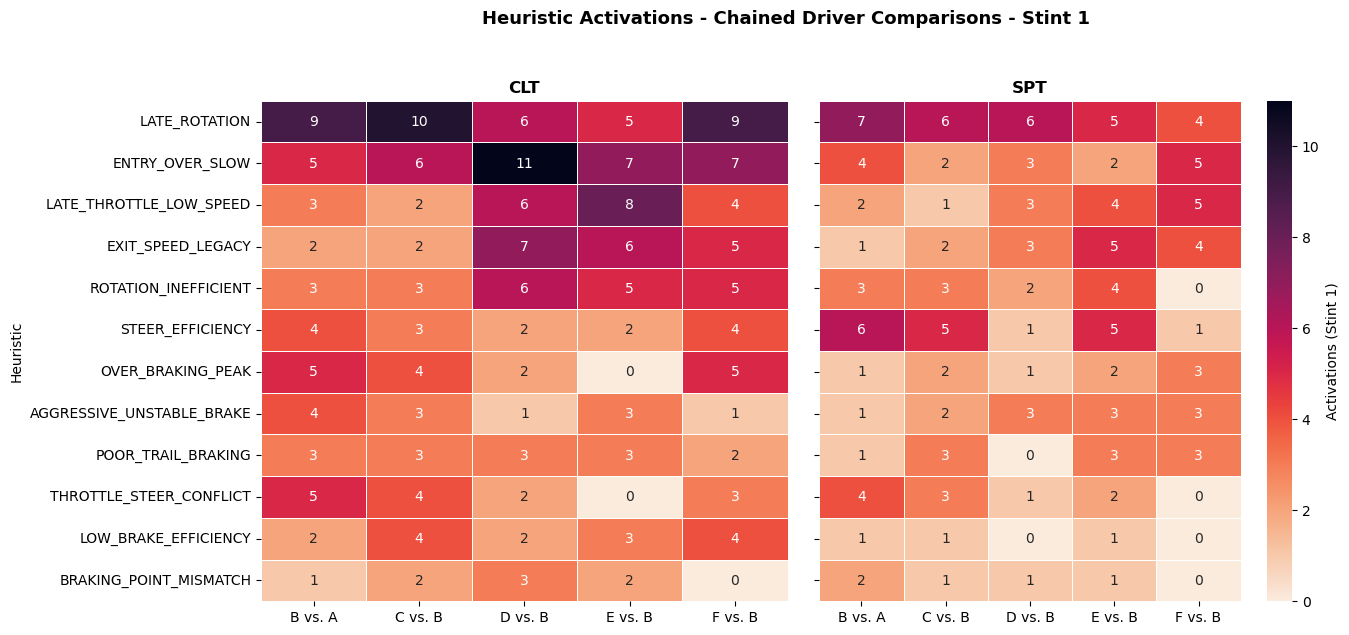

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), sharey=True,
                         gridspec_kw={"wspace": 0.06,
                                      "width_ratios": [snap["CLT"].shape[1] if "CLT" in snap else 1,
                                                       snap["SPT"].shape[1] if "SPT" in snap else 1]})
vmax = snap.values.max()
for ax, track in zip(axes, ["CLT", "SPT"]):
    sns.heatmap(snap[track], annot=True, fmt="d", cmap="rocket_r", vmin=0, vmax=vmax,
                cbar=(track == "SPT"), ax=ax, linewidths=0.6, linecolor="white",
                cbar_kws={"label": "Activations (Stint 1)"})
    ax.set_title(track, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Heuristic" if track == "CLT" else "")
    ax.tick_params(axis="x", rotation=0)
fig.suptitle("Heuristic Activations - Chained Driver Comparisons - Stint 1",
             fontsize=13, fontweight="bold", y=1.02)
plt.savefig(SAVE_DIR / "fig_heuristics_stint1_heatmap.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 8. Longitudinal analysis — activations along stints

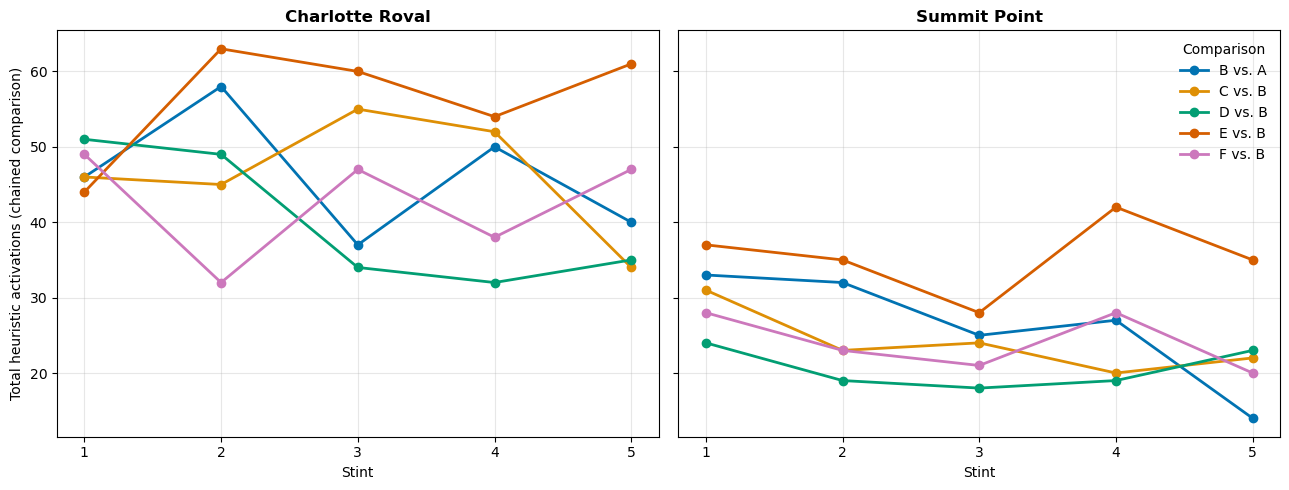

StintN               1     2     3     4     5
Track Comparison                              
CLT   B vs. A     46.0  58.0  37.0  50.0  40.0
      C vs. B     46.0  45.0  55.0  52.0  34.0
      D vs. B     51.0  49.0  34.0  32.0  35.0
      E vs. B     44.0  63.0  60.0  54.0  61.0
      F vs. B     49.0  32.0  47.0  38.0  47.0
SPT   B vs. A     33.0  32.0  25.0  27.0  14.0
      C vs. B     31.0  23.0  24.0  20.0  22.0
      D vs. B     24.0  19.0  18.0  19.0  23.0
      E vs. B     37.0  35.0  28.0  42.0  35.0
      F vs. B     28.0  23.0  21.0  28.0  20.0

In [10]:
tot = df_long.groupby(["Track", "Comparison", "Stint"], as_index=False)["Fired"].sum()
tot["StintN"] = tot["Stint"].str.extract(r"(\d+)").astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
palette = dict(zip(comp_order, sns.color_palette("colorblind", len(comp_order))))
for ax, track in zip(axes, ["CLT", "SPT"]):
    sub = tot[tot["Track"] == track]
    for comp, g in sub.groupby("Comparison"):
        g = g.sort_values("StintN")
        ax.plot(g["StintN"], g["Fired"], marker="o", linewidth=2,
                color=palette[comp], label=comp)
    ax.set_title({"CLT": "Charlotte Roval", "SPT": "Summit Point"}[track],
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Stint")
    ax.set_xticks(sorted(sub["StintN"].unique()))
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Total heuristic activations (chained comparison)")
axes[1].legend(title="Comparison", frameon=False, loc="upper right")
plt.tight_layout()
plt.savefig(SAVE_DIR / "fig_activations_per_stint_lines.pdf", dpi=300, bbox_inches="tight")
plt.show()

tot.pivot_table(index=["Track", "Comparison"], columns="StintN", values="Fired")

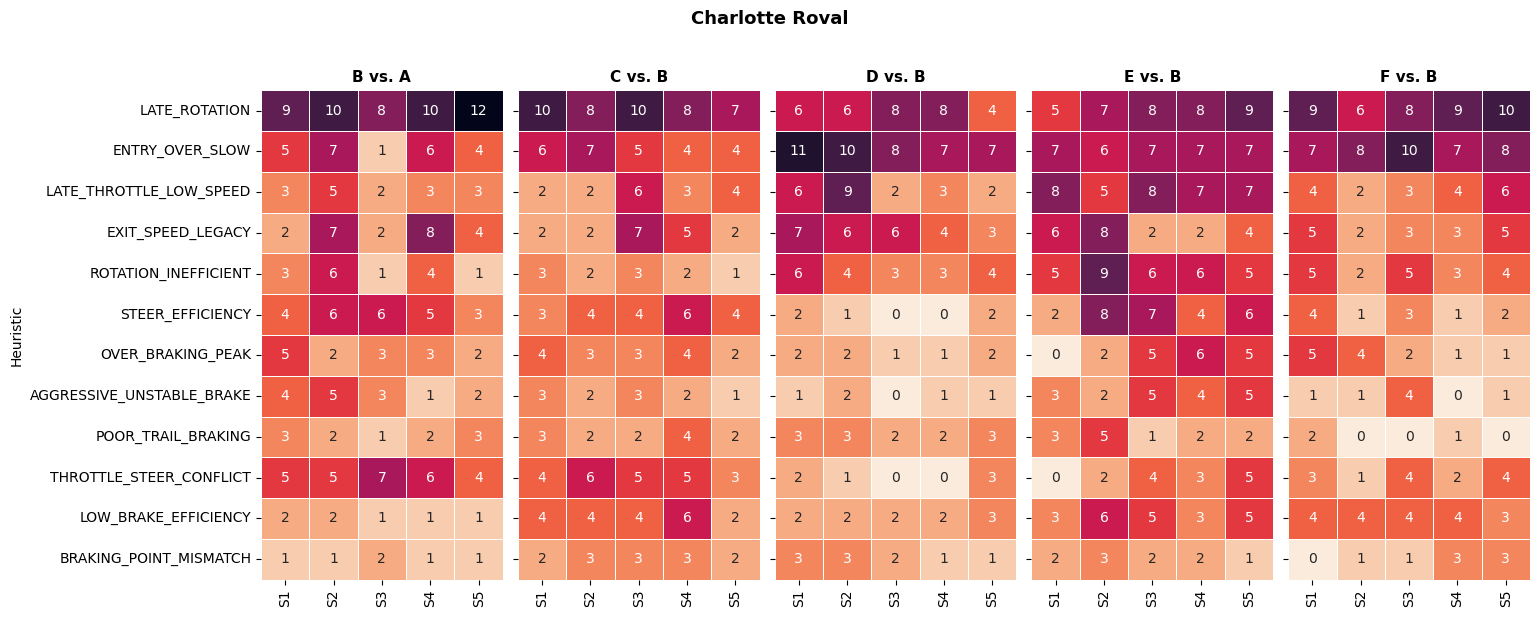

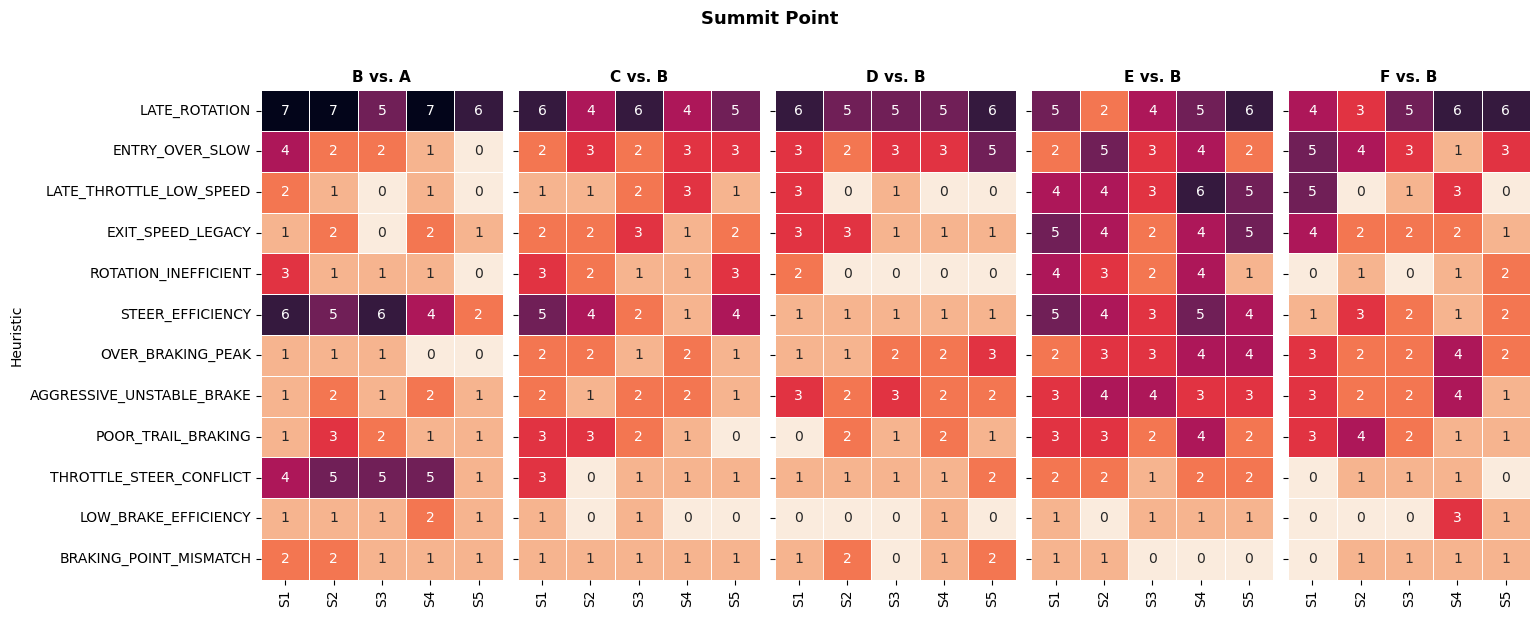

In [11]:
for track in ["CLT", "SPT"]:
    sub = df_long[df_long["Track"] == track]
    comps = [c for c in comp_order if c in sub["Comparison"].unique()]
    fig, axes = plt.subplots(1, len(comps), figsize=(3.1 * len(comps), 6), sharey=True)
    if len(comps) == 1:
        axes = [axes]
    vmax = sub["Fired"].max()
    for ax, comp in zip(axes, comps):
        piv = (sub[sub["Comparison"] == comp]
               .pivot_table(index="Rule_ID", columns="Stint", values="Fired", fill_value=0)
               .reindex(snap.index))
        sns.heatmap(piv, annot=True, fmt=".0f", cmap="rocket_r", vmin=0, vmax=vmax,
                    cbar=False, ax=ax, linewidths=0.5, linecolor="white")
        ax.set_title(comp, fontsize=11, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Heuristic" if ax is axes[0] else "")
        ax.set_xticklabels([c.get_text().replace("stint_", "S") for c in ax.get_xticklabels()])
    fig.suptitle("Charlotte Roval" if track == "CLT" else "Summit Point",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(SAVE_DIR / f"fig_heuristics_stints_{track.lower()}.pdf",
                dpi=300, bbox_inches="tight")
    plt.show()

## 9. Threshold sensitivity

Two complementary designs, because neither is sufficient alone.

**One-at-a-time (§9.2).** Perturbs one threshold at a time. Good for locating the
breaking point of each individual rule, but a poor global stability measure: with 17
parameters each feeding 1–2 of 12 rules, at least 10 rule counts are *identical* to
baseline in every OAT scenario, so a rank correlation against baseline is close to 1
by construction. Reported here with that caveat stated explicitly.

**Joint Monte Carlo (§9.4).** Draws all 17 factors simultaneously from
$\mathcal{U}(0.5, 1.5)$. Every rule moves at once, so the rank correlation and the
longitudinal trend are genuinely stressed. This is the number that belongs in the
response letter.

**Stability criteria.** Rather than a binary flag, the longitudinal pattern is
summarised by two continuous quantities:

- `slope_fb` — mean per-stint slope of the feedback pairs (expected negative);
- `margin` — `slope_ctrl - slope_fb` (expected positive; how far the control sits
  above the treated pairs).

A scenario "preserves the pattern" when `slope_fb < 0` and `margin > 0`, but the
magnitudes are what get reported.

In [12]:
import re as _re
from scipy.stats import kendalltau

def stint_num(s):
    m = _re.search(r"(\d+)", str(s))
    return int(m.group(1)) if m else 0


def stint_slopes(df_act):
    """Least-squares slope of total activations vs stint index, per (track, comparison)."""
    tot = df_act.groupby(["Track", "Comparison", "Stint"])["Fired"].sum().reset_index()
    tot["StintN"] = tot["Stint"].map(stint_num)
    out = {}
    for (track, comp), g in tot.groupby(["Track", "Comparison"]):
        g = g.sort_values("StintN")
        if len(g) >= 3:
            out[(track, comp)] = float(np.polyfit(g["StintN"], g["Fired"], 1)[0])
    return out


def pattern_stats(slopes):
    """Continuous summary of the longitudinal pattern (replaces the v2 boolean)."""
    fb = [v for (t, c), v in slopes.items() if c in FEEDBACK_PAIRS]
    ct = [v for (t, c), v in slopes.items() if c == CONTROL_PAIR]
    if not fb or not ct:
        return {"slope_fb": np.nan, "slope_ctrl": np.nan,
                "margin": np.nan, "preserved": None}
    slope_fb, slope_ct = float(np.mean(fb)), float(np.mean(ct))
    return {"slope_fb": slope_fb, "slope_ctrl": slope_ct,
            "margin": slope_ct - slope_fb,
            "preserved": bool(slope_fb < 0 and slope_ct > slope_fb)}


def scenario_summary(df_act, base_rank):
    tot  = df_act.groupby("Rule_ID")["Fired"].sum().reindex(RULE_IDS).fillna(0)
    tau  = kendalltau(base_rank, tot.rank(ascending=False))[0]
    stats = pattern_stats(stint_slopes(df_act))
    return {"Total": int(tot.sum()), "KendallTau": float(tau), **stats}, tot


# --- Baseline ------------------------------------------------------------------
base_tot  = df_sector.groupby("Rule_ID")["Fired"].sum().reindex(RULE_IDS).fillna(0)
base_rank = base_tot.rank(ascending=False)
base_stats, _ = scenario_summary(df_sector, base_rank)

chk = df_long.groupby("Rule_ID")["Fired"].sum()
assert (base_tot.reindex(chk.index).fillna(0) == chk).all(), \
    "baseline evaluation != df_long - investigate before trusting section 9"

print("Baseline reproduced df_long exactly.")
print(f"Baseline slope (feedback pairs) : {base_stats['slope_fb']:+.2f} activations/stint")
print(f"Baseline slope (control pair)   : {base_stats['slope_ctrl']:+.2f} activations/stint")
print(f"Baseline margin (ctrl - fb)     : {base_stats['margin']:+.2f}")
print()
print(base_tot.sort_values(ascending=False).astype(int).to_string())

Baseline reproduced df_long exactly.
Baseline slope (feedback pairs) : -2.01 activations/stint
Baseline slope (control pair)   : +1.40 activations/stint
Baseline margin (ctrl - fb)     : +3.41

Rule_ID
LATE_ROTATION                333
ENTRY_OVER_SLOW              236
EXIT_SPEED_LEGACY            163
STEER_EFFICIENCY             162
LATE_THROTTLE_LOW_SPEED      156
ROTATION_INEFFICIENT         132
THROTTLE_STEER_CONFLICT      128
OVER_BRAKING_PEAK            119
AGGRESSIVE_UNSTABLE_BRAKE    113
POOR_TRAIL_BRAKING           101
LOW_BRAKE_EFFICIENCY          96
BRAKING_POINT_MISMATCH        71


### 9.2 One-at-a-time sweep

Factors extend to 0.25x and 3.0x deliberately. Reporting only a narrow band invites
the objection that the analysis was tuned to pass; showing where each rule breaks is
more informative than showing it never breaks. Output is tidy (one row per
parameter x factor x affected rule), not the wide NaN-filled frame v2 produced.

In [13]:
FACTORS = [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0]

scen_rows, act_rows = [], []
for param in THRESHOLD_SPEC:
    for f in FACTORS:
        df_s = df_sector if f == 1.0 else evaluate_rules(pair_cache, thresholds_at({param: f}))
        summ, tot = scenario_summary(df_s, base_rank)
        eff = thresholds_at({param: f})[param]
        scen_rows.append({"Param": param, "Factor": f, "EffectiveThreshold": eff, **summ})
        for rid in PARAM_RULES[param]:
            n0 = int(base_tot[rid])
            act_rows.append({"Param": param, "Factor": f, "Rule_ID": rid,
                             "Activations": int(tot[rid]),
                             "RelChange_%": np.nan if n0 == 0 else round(100 * (tot[rid] - n0) / n0, 1)})

df_scen = pd.DataFrame(scen_rows)
df_act  = pd.DataFrame(act_rows)
df_scen.to_csv(SAVE_DIR / "sensitivity_oat_scenarios.csv", index=False)
df_act.to_csv(SAVE_DIR / "sensitivity_oat_activations.csv", index=False)

pert = df_scen[df_scen["Factor"] != 1.0]
n_keep = int((pert["preserved"] == True).sum())
print(f"{len(pert)} OAT scenarios | pattern preserved in {n_keep}/{len(pert)} "
      f"({100 * n_keep / len(pert):.0f}%)")
print(f"Kendall tau range : {pert['KendallTau'].min():.3f} - {pert['KendallTau'].max():.3f}")
print("  CAVEAT: under OAT at least 10 of 12 rule counts are unchanged by construction,")
print("  so tau near 1 is expected regardless of robustness. See section 9.4.")
print(f"Total activations : {pert['Total'].min()} - {pert['Total'].max()} "
      f"(baseline {base_stats['Total']})")
print(f"Feedback slope    : {pert['slope_fb'].min():+.2f} to {pert['slope_fb'].max():+.2f} "
      f"(baseline {base_stats['slope_fb']:+.2f})")

bad = pert[pert["preserved"] != True]
print("\nScenarios NOT preserving the longitudinal pattern:")
print(bad[["Param", "Factor", "slope_fb", "margin"]].round(3).to_string(index=False)
      if not bad.empty else "  none")

# Rules whose activation count is most/least sensitive within the +-50% band
band = df_act[(df_act["Factor"].between(0.5, 1.5)) & (df_act["Factor"] != 1.0)]
sens_rank = (band.groupby("Rule_ID")["RelChange_%"].apply(lambda s: s.abs().max())
             .sort_values(ascending=False).round(1))
print("\nMax |relative change| within the +-50% band, per rule:")
print(sens_rank.to_string())

119 OAT scenarios | pattern preserved in 119/119 (100%)
Kendall tau range : 0.727 - 1.000
  CAVEAT: under OAT at least 10 of 12 rule counts are unchanged by construction,
  so tau near 1 is expected regardless of robustness. See section 9.4.
Total activations : 1699 - 1917 (baseline 1810)
Feedback slope    : -2.20 to -1.69 (baseline -2.01)

Scenarios NOT preserving the longitudinal pattern:
  none

Max |relative change| within the +-50% band, per rule:
Rule_ID
BRAKING_POINT_MISMATCH       94.4
LOW_BRAKE_EFFICIENCY         58.3
OVER_BRAKING_PEAK            40.3
STEER_EFFICIENCY             35.2
THROTTLE_STEER_CONFLICT      35.2
EXIT_SPEED_LEGACY            33.7
POOR_TRAIL_BRAKING           26.7
ROTATION_INEFFICIENT         22.0
LATE_THROTTLE_LOW_SPEED      16.0
ENTRY_OVER_SLOW              13.1
LATE_ROTATION                10.2
AGGRESSIVE_UNSTABLE_BRAKE     8.0


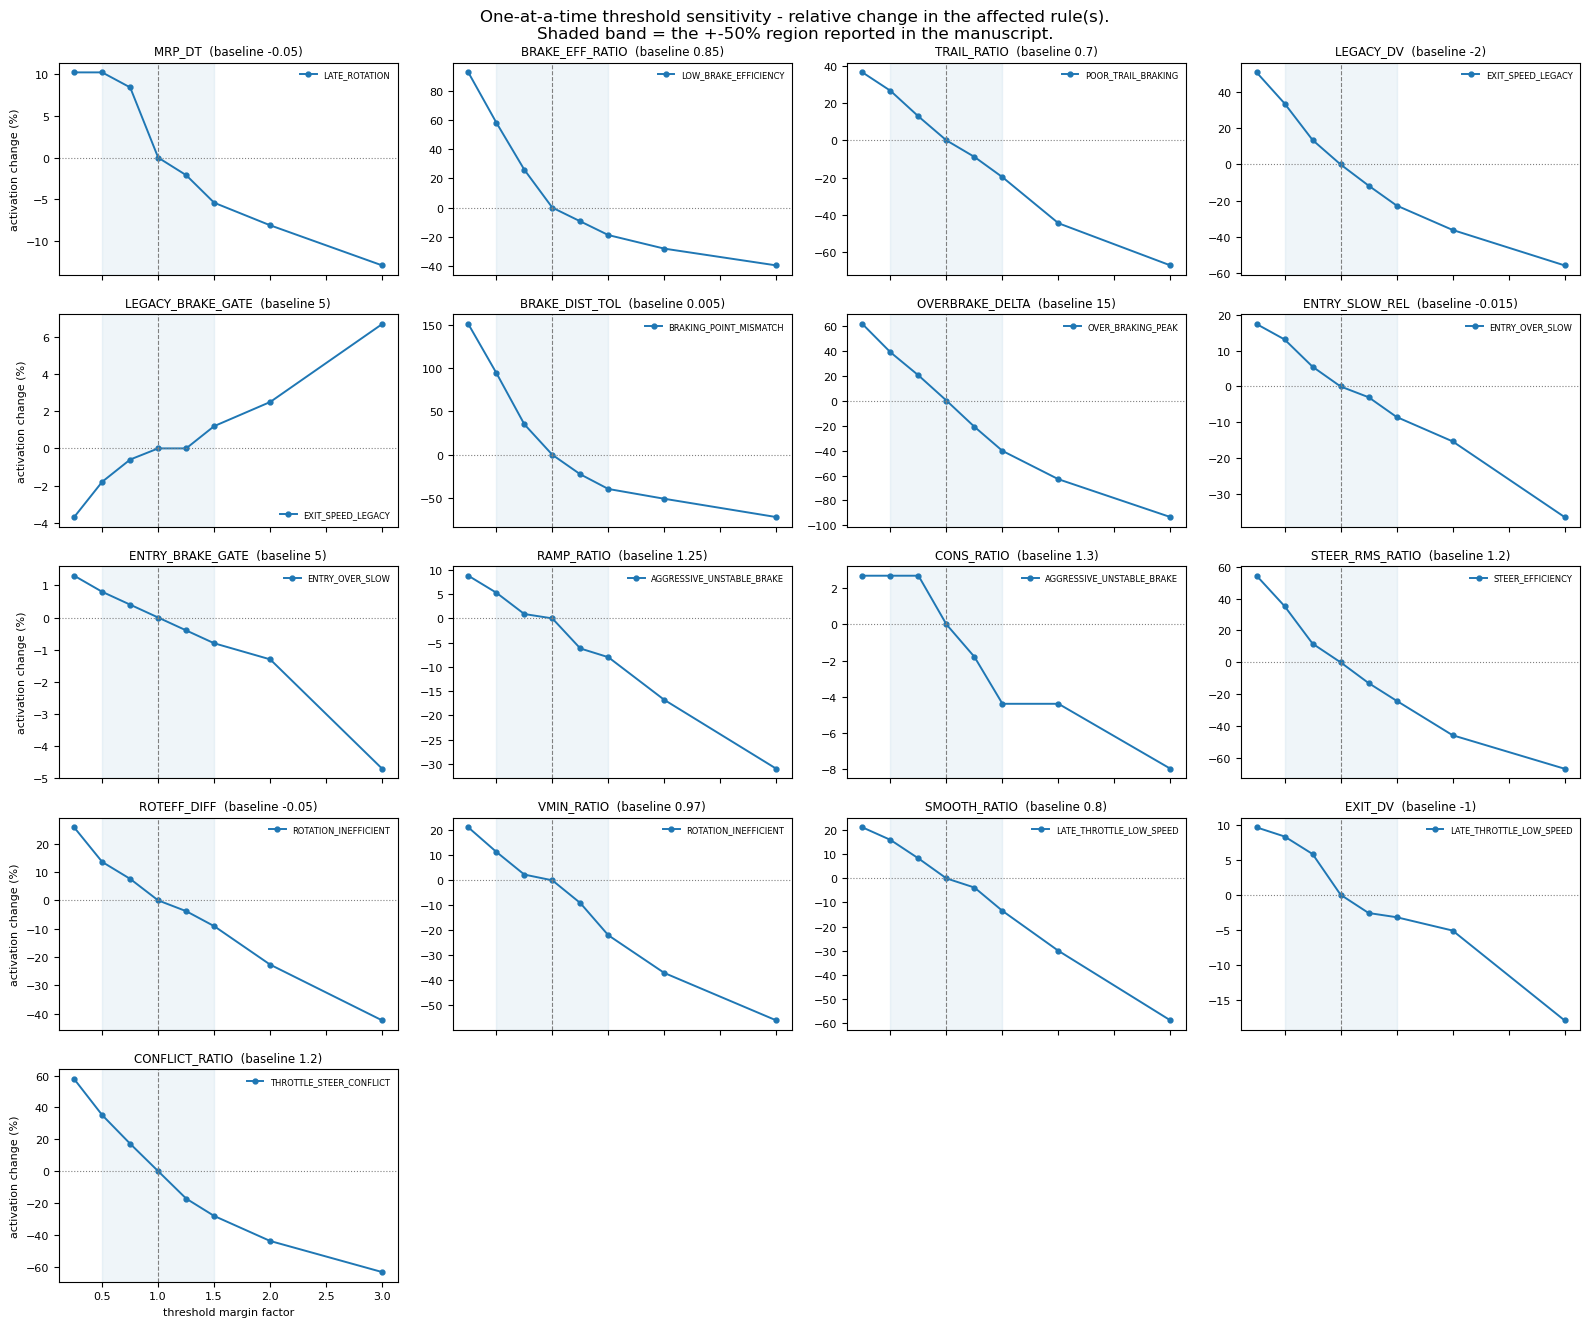

In [14]:
# --- OAT curves: relative change, comparable across panels ---------------------
params = list(THRESHOLD_SPEC)
ncols  = 4
nrows  = int(np.ceil(len(params) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 2.7 * nrows), sharex=True)

for ax, param in zip(axes.flat, params):
    sub = df_act[df_act["Param"] == param]
    for rid, g in sub.groupby("Rule_ID"):
        g = g.sort_values("Factor")
        ax.plot(g["Factor"], g["RelChange_%"], marker="o", ms=3.5, lw=1.4, label=rid)
    ax.axvline(1.0, color="grey", lw=0.8, ls="--")
    ax.axhline(0.0, color="grey", lw=0.8, ls=":")
    ax.axvspan(0.5, 1.5, color="tab:blue", alpha=0.07)
    base = THRESHOLD_SPEC[param]
    ax.set_title(f"{param}  (baseline {base[0] + base[1]:.4g})", fontsize=8.5)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=6, frameon=False)

for ax in axes.flat[len(params):]:
    ax.set_visible(False)
for ax in axes[-1]:
    ax.set_xlabel("threshold margin factor", fontsize=8)
for ax in axes[:, 0]:
    ax.set_ylabel("activation change (%)", fontsize=8)

fig.suptitle("One-at-a-time threshold sensitivity - relative change in the affected rule(s).\n"
             "Shaded band = the +-50% region reported in the manuscript.", fontsize=12)
fig.tight_layout()
fig.savefig(SAVE_DIR / "fig_sensitivity_oat_curves.pdf", dpi=300, bbox_inches="tight")
plt.show()

### 9.4 Joint Monte Carlo perturbation

All 17 factors drawn simultaneously from $\mathcal{U}(0.5, 1.5)$. Unlike OAT, every
rule moves in every draw, so Kendall tau against the baseline ranking is a real test.
Reported: the distribution of tau, of total activations, and the fraction of draws
in which the longitudinal pattern survives.

In [15]:
N_MC = 300
LO, HI = 0.5, 1.5

mc_rows = []
for i in range(N_MC):
    factors = {p: float(RNG.uniform(LO, HI)) for p in THRESHOLD_SPEC}
    df_s = evaluate_rules(pair_cache, thresholds_at(factors))
    summ, _ = scenario_summary(df_s, base_rank)
    mc_rows.append({"Draw": i, **summ})

df_mc = pd.DataFrame(mc_rows)
df_mc.to_csv(SAVE_DIR / "sensitivity_joint_montecarlo.csv", index=False)

q = df_mc["KendallTau"].quantile([0.05, 0.5, 0.95])
keep = float((df_mc["preserved"] == True).mean())
print(f"=== Joint perturbation: {N_MC} draws, all thresholds ~ U({LO}, {HI}) ===")
print(f"Kendall tau   : median {q[0.5]:.3f} | 5th pct {q[0.05]:.3f} | min {df_mc['KendallTau'].min():.3f}")
print(f"Total activ.  : median {df_mc['Total'].median():.0f} "
      f"(baseline {base_stats['Total']}), range {df_mc['Total'].min()}-{df_mc['Total'].max()}")
print(f"Feedback slope: median {df_mc['slope_fb'].median():+.2f} "
      f"(baseline {base_stats['slope_fb']:+.2f}), "
      f"negative in {100 * (df_mc['slope_fb'] < 0).mean():.1f}% of draws")
print(f"Pattern preserved in {100 * keep:.1f}% of draws")
display(df_mc[["KendallTau", "Total", "slope_fb", "slope_ctrl", "margin"]].describe().round(3))

=== Joint perturbation: 300 draws, all thresholds ~ U(0.5, 1.5) ===
Kendall tau   : median 0.758 | 5th pct 0.606 | min 0.473
Total activ.  : median 1836 (baseline 1810), range 1664-2049
Feedback slope: median -1.79 (baseline -2.01), negative in 100.0% of draws
Pattern preserved in 100.0% of draws


,KendallTau,Total,slope_fb,slope_ctrl,margin
count,300.000,300.000,300.000,300.000,300.000
mean,0.764,1840.030,-1.795,1.048,2.842
std,0.091,67.648,0.199,0.351,0.384
min,0.473,1664.000,-2.363,0.200,1.925
25%,0.697,1794.750,-1.928,0.800,2.575
50%,0.758,1836.500,-1.794,1.050,2.850
75%,0.840,1881.000,-1.650,1.250,3.125
max,0.939,2049.000,-1.238,2.150,3.887


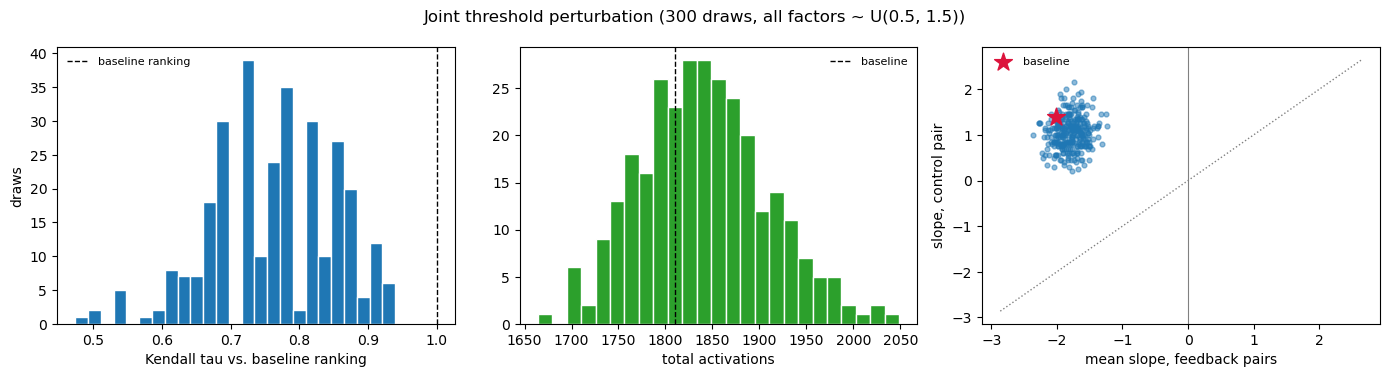

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

axes[0].hist(df_mc["KendallTau"], bins=25, color="tab:blue", edgecolor="white")
axes[0].axvline(1.0, color="k", ls="--", lw=1, label="baseline ranking")
axes[0].set_xlabel("Kendall tau vs. baseline ranking")
axes[0].set_ylabel("draws")
axes[0].legend(fontsize=8, frameon=False)

axes[1].hist(df_mc["Total"], bins=25, color="tab:green", edgecolor="white")
axes[1].axvline(base_stats["Total"], color="k", ls="--", lw=1, label="baseline")
axes[1].set_xlabel("total activations")
axes[1].legend(fontsize=8, frameon=False)

axes[2].scatter(df_mc["slope_fb"], df_mc["slope_ctrl"], s=12, alpha=0.5)
lim = [min(df_mc["slope_fb"].min(), df_mc["slope_ctrl"].min()) - 0.5,
       max(df_mc["slope_fb"].max(), df_mc["slope_ctrl"].max()) + 0.5]
axes[2].plot(lim, lim, color="grey", ls=":", lw=1)
axes[2].axvline(0, color="grey", lw=0.8)
axes[2].scatter([base_stats["slope_fb"]], [base_stats["slope_ctrl"]],
                marker="*", s=180, color="crimson", zorder=5, label="baseline")
axes[2].set_xlabel("mean slope, feedback pairs")
axes[2].set_ylabel("slope, control pair")
axes[2].legend(fontsize=8, frameon=False)

fig.suptitle(f"Joint threshold perturbation ({N_MC} draws, all factors ~ U({LO}, {HI}))",
             fontsize=12)
fig.tight_layout()
fig.savefig(SAVE_DIR / "fig_sensitivity_joint_mc.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 10. Negative control — self-comparison

Specificity check: comparing Driver B's own stints against Driver B's reference lap
should activate far fewer rules than a cross-driver comparison, since only
intra-driver variability remains.

Computed under **both** threshold sets. The prediction is that the corrected
thresholds separate self from cross-driver more cleanly, because a large share of the
pre-correction self-activations came from `OVER_BRAKING_PEAK` firing on a 0.15 p.p.
margin — i.e. on pedal noise. If the prediction holds, the correction improved the
engine's specificity, which is a point worth making in the response letter.

In [17]:
SELF = {"ref": "Tomaz", "ref_stint": "stint_ref", "test": "Tomaz",
        "label": "B vs. B (self)"}


def self_pair_cache(dp):
    out = {}
    for track, cfg in DATASETS.items():
        if SELF["test"] not in cfg["sessions"] or SELF["ref"] not in cfg["sessions"]:
            continue
        edges = TRACK_CONFIGS[track]["custom_edges"]
        try:
            interp_ref = load_best_lap_interp(track, SELF["ref"], SELF["ref_stint"])[0]
        except Exception as e:
            print(f"[SKIP] {track} self ref -> {e}")
            continue
        heur_ref = compute_sector_heuristics(interp_ref, edges, dp)
        for stint in sorted(k for k in cfg["sessions"][SELF["test"]] if k not in EXCLUDE_STINTS):
            try:
                interp_t = load_best_lap_interp(track, SELF["test"], stint)[0]
            except Exception as e:
                print(f"[SKIP] {track} self {stint} -> {e}")
                continue
            heur_t = compute_sector_heuristics(interp_t, edges, dp)
            out[(TRACK_SHORT[track], SELF["label"], stint)] = (heur_ref, heur_t)
    return build_pair_cache(out)


rows = []
for tag, dp, spec in (("Corrected (v3)", DESC_SPEC, THRESHOLD_SPEC),
                      ("Legacy (v2)",    DESC_LEGACY, THRESHOLD_SPEC_LEGACY)):
    pc     = self_pair_cache(dp)
    df_s   = evaluate_rules(pc, thresholds_at(spec=spec))
    self_t = df_s.groupby(["Track", "Stint"])["Fired"].sum()
    cross  = (df_sector if tag.startswith("Corrected") else df_legacy)
    cross_t = cross.groupby(["Track", "Comparison", "Stint"])["Fired"].sum()
    rows.append({"Thresholds": tag,
                 "Self mean":  round(self_t.mean(), 1),
                 "Self max":   int(self_t.max()),
                 "Cross mean": round(cross_t.mean(), 1),
                 "Cross min":  int(cross_t.min()),
                 "Ratio":      round(cross_t.mean() / max(self_t.mean(), 1e-9), 2)})
    if tag.startswith("Corrected"):
        df_self_detail = self_t.reset_index(name="Activations")
        df_self_rules  = df_s.groupby("Rule_ID")["Fired"].sum().sort_values(ascending=False)

df_ctrl = pd.DataFrame(rows)
print("=== Negative control: self vs cross-driver activations per stint ===")
display(df_ctrl)
print("\nSelf-comparison activations per stint (corrected thresholds):")
display(df_self_detail)
print("\nWhich rules still fire on self-comparison (corrected):")
print(df_self_rules.astype(int).to_string())


=== Negative control: self vs cross-driver activations per stint ===


,Thresholds,Self mean,Self max,Cross mean,Cross min,Ratio
0,Corrected (v3),25.3,39,36.2,14,1.43
1,Legacy (v2),27.8,42,38.8,16,1.39



Self-comparison activations per stint (corrected thresholds):


,Track,Stint,Activations
0,CLT,stint_1,31
1,CLT,stint_2,39
2,CLT,stint_3,26
3,CLT,stint_4,38
4,CLT,stint_5,28
5,SPT,stint_1,22
6,SPT,stint_2,20
7,SPT,stint_3,15
8,SPT,stint_4,22
9,SPT,stint_5,12



Which rules still fire on self-comparison (corrected):
Rule_ID
LATE_ROTATION                81
ENTRY_OVER_SLOW              29
STEER_EFFICIENCY             28
THROTTLE_STEER_CONFLICT      23
LATE_THROTTLE_LOW_SPEED      21
POOR_TRAIL_BRAKING           18
EXIT_SPEED_LEGACY            14
LOW_BRAKE_EFFICIENCY         14
AGGRESSIVE_UNSTABLE_BRAKE     8
ROTATION_INEFFICIENT          8
BRAKING_POINT_MISMATCH        7
OVER_BRAKING_PEAK             2


## 12. Convergent validity — activations vs. sector time loss

If the heuristics capture genuine causes of time loss, sectors **with** an activation
should concentrate larger $\Delta t$ than sectors without, and the activation count
should correlate positively with sector $\Delta t$.

This is the strongest empirical answer available to "not independently validated": it
does not assume the thresholds are right, it tests whether their output tracks an
outcome measured independently of them.

Sector pairs analysed          : 700
Spearman rho (N_Act vs DeltaT) : 0.371  (p = 2.75e-24)
Median DeltaT | no activation  : 0.021 s  (n = 34)
Median DeltaT | >=1 activation : 0.147 s  (n = 666)
Mann-Whitney U (one-sided)     : p = 7.44e-06
Cliff's delta                  : 0.440

Per-comparison Spearman rho:


,Track,Comparison,Spearman_rho
0,CLT,B vs. A,0.256
1,CLT,C vs. B,0.523
2,CLT,D vs. B,0.418
3,CLT,E vs. B,0.325
4,CLT,F vs. B,0.495
5,SPT,B vs. A,0.674
6,SPT,C vs. B,0.537
7,SPT,D vs. B,0.053
8,SPT,E vs. B,0.289
9,SPT,F vs. B,0.417


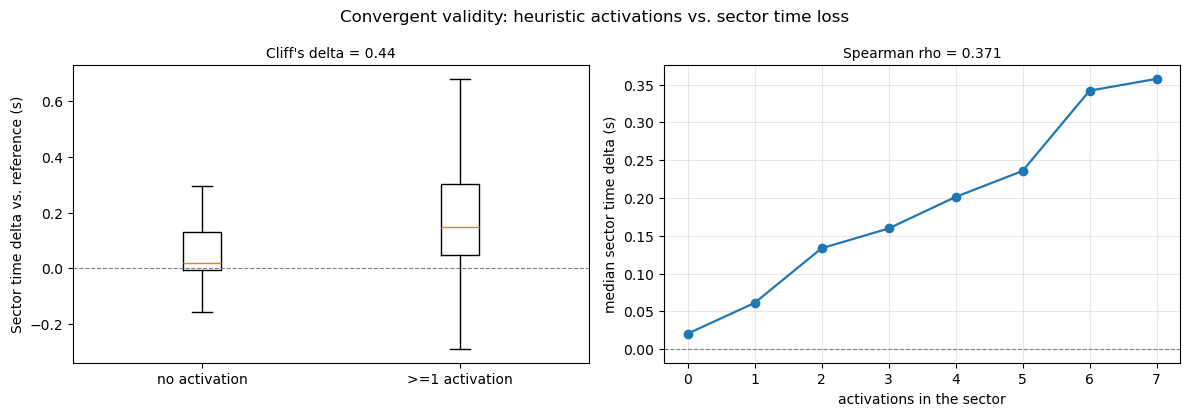

In [18]:
from scipy.stats import spearmanr, mannwhitneyu

sector_act = (df_sector.groupby(["Track", "Comparison", "Stint", "Sector"])["Fired"]
              .sum().reset_index(name="N_Act"))
dt_rows = [{"Track": t, "Comparison": c, "Stint": s, "Sector": sec, "DeltaT_s": dts}
           for (t, c, s), pairs in pair_cache.items()
           for sec, A, B, dts in pairs]
df_conv = (sector_act.merge(pd.DataFrame(dt_rows),
                            on=["Track", "Comparison", "Stint", "Sector"], how="inner")
           .dropna(subset=["DeltaT_s"]))

rho, p_rho = spearmanr(df_conv["N_Act"], df_conv["DeltaT_s"])
g0 = df_conv.loc[df_conv["N_Act"] == 0, "DeltaT_s"]
g1 = df_conv.loc[df_conv["N_Act"] > 0, "DeltaT_s"]
u_stat, p_u = mannwhitneyu(g1, g0, alternative="greater")
cliffs = 2 * u_stat / (len(g0) * len(g1)) - 1   # Cliff's delta

print(f"Sector pairs analysed          : {len(df_conv)}")
print(f"Spearman rho (N_Act vs DeltaT) : {rho:.3f}  (p = {p_rho:.2e})")
print(f"Median DeltaT | no activation  : {g0.median():.3f} s  (n = {len(g0)})")
print(f"Median DeltaT | >=1 activation : {g1.median():.3f} s  (n = {len(g1)})")
print(f"Mann-Whitney U (one-sided)     : p = {p_u:.2e}")
print(f"Cliff's delta                  : {cliffs:.3f}")

per_comp = (df_conv.groupby(["Track", "Comparison"])[["N_Act", "DeltaT_s"]]
            .apply(lambda g: spearmanr(g["N_Act"], g["DeltaT_s"])[0] if len(g) > 5 else np.nan)
            .rename("Spearman_rho").reset_index())
print("\nPer-comparison Spearman rho:")
display(per_comp.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].boxplot([g0, g1], tick_labels=["no activation", ">=1 activation"], showfliers=False)
axes[0].axhline(0, color="grey", lw=0.8, ls="--")
axes[0].set_ylabel("Sector time delta vs. reference (s)")
axes[0].set_title(f"Cliff's delta = {cliffs:.2f}", fontsize=10)

by_n = df_conv.groupby("N_Act")["DeltaT_s"].agg(["median", "count"])
by_n = by_n[by_n["count"] >= 5]
axes[1].plot(by_n.index, by_n["median"], marker="o", lw=1.6)
axes[1].axhline(0, color="grey", lw=0.8, ls="--")
axes[1].set_xlabel("activations in the sector")
axes[1].set_ylabel("median sector time delta (s)")
axes[1].set_title(f"Spearman rho = {rho:.3f}", fontsize=10)
axes[1].grid(alpha=0.3)

fig.suptitle("Convergent validity: heuristic activations vs. sector time loss", fontsize=12)
fig.tight_layout()
fig.savefig(SAVE_DIR / "fig_convergent_validity.pdf", dpi=300, bbox_inches="tight")
plt.show()
df_conv.to_csv(SAVE_DIR / "convergent_validity_sector_level.csv", index=False)
per_comp.to_csv(SAVE_DIR / "convergent_validity_per_comparison.csv", index=False)